# Customer Behavior EDA (Legacy Monolith)

This notebook is retained for reference.

Split notebooks for active work:
- `02a_customer_kpi_segments.ipynb`
- `02b_customer_retention_clv.ipynb`
- `02c_customer_trends_diagnostics.ipynb`

In [ ]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

In [11]:
DATA_PATH = '../../data/processed/quality'

orders = pd.read_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior = pd.read_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train = pd.read_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products = pd.read_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles = pd.read_csv(Path(DATA_PATH) / 'aisles_clean.csv')
departments = pd.read_csv(Path(DATA_PATH) / 'departments_clean.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments,
}


df = tables['orders'].merge(order_products_prior, on='order_id', how='inner')

order_dates_df = pd.read_csv('../../data/processed/features/orders_with_dates.csv')
order_dates_df['order_date'] = pd.to_datetime(order_dates_df['order_date'])

df = df.merge(
    order_dates_df[['order_id', 'order_date']], 
    on='order_id', 
    how='left'
)

# สกัดฟีเจอร์เพิ่มเติม
df['order_month'] = df['order_date'].dt.month
df['order_year_month'] = df['order_date'].dt.to_period('M')

# 3. เชื่อมข้อมูลรายละเอียดสินค้า (Products)
df = df.merge(tables['products'], on='product_id', how='left')
# 4. เชื่อมข้อมูลหมวดหมู่ (Aisles และ Departments)
df = df.merge(tables['aisles'], on='aisle_id', how='left')
df = df.merge(tables['departments'], on='department_id', how='left')

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_id', 'add_to_cart_order', 'reordered', 'order_date', 'order_month', 'order_year_month', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']



,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,order_date,order_month,order_year_month,product_name,aisle_id,department_id,aisle,department
0,2539329,1,prior,1,2,8,0.0,196,1,0,2014-12-23,12,2014-12,Soda,77,7,soft drinks,beverages
1,2539329,1,prior,1,2,8,0.0,14084,2,0,2014-12-23,12,2014-12,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs
2,2539329,1,prior,1,2,8,0.0,12427,3,0,2014-12-23,12,2014-12,Original Beef Jerky,23,19,popcorn jerky,snacks
3,2539329,1,prior,1,2,8,0.0,26088,4,0,2014-12-23,12,2014-12,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks
4,2539329,1,prior,1,2,8,0.0,26405,5,0,2014-12-23,12,2014-12,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household


In [12]:
def show_df(df, title):
    """
    ฟังก์ชันสำหรับแสดงผล DataFrame พร้อมหัวข้อ Markdown
    """
    display(Markdown(f"#### {title}"))
    display(df)

## 1) Data Setup & KPI Baseline

**Data Mode Configuration**

ส่วนนี้ใช้ตั้งค่า environment และสร้าง baseline KPI ต่อผู้ใช้เพื่อดูภาพรวมก่อนลงลึก

In [13]:
# 1. สร้างคอลัมน์ cumulative reorder (ใช้ Index เดิมของ df)
df["cumulative_reorder_per_customer"] = (
    df.groupby("user_id")["reordered"]
    .cumsum()
)

# 2. คำนวณ Customer KPI
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)

# 3. จัดการเรื่อง Display (ย้าย Markdown ไปไว้รวมกันได้)
from IPython.display import display, Markdown

display(Markdown("### Customer KPI summary:"))
# แนะนำให้ใช้ .T (Transpose) เพื่อให้อ่านง่ายขึ้นถ้าคอลัมน์เยอะ
display(customer_kpi.drop(columns=["user_id"]).describe(include="all").T)

display(Markdown("### Customer KPI detailed summary:"))
# แนะนำให้ใช้ .T (Transpose) เพื่อให้อ่านง่ายขึ้นถ้าคอลัมน์เยอะ
display(customer_kpi.describe(include="all").T)

# 4. Summary by reordered
summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        median_days_since_prior=("days_since_prior_order", "median"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)

display(Markdown("### Summary by reordered:"))
display(summary_by_reordered)

### Customer KPI summary:

,count,mean,std,min,25%,50%,75%,max
total_orders,206209.0,15.590367,16.654774,3.0,5.000000,9.000000,19.000000,99.000000
total_lines,206209.0,157.289396,204.208233,3.0,39.000000,83.000000,188.000000,3725.000000
reorder_rate,206209.0,0.432249,0.212144,0.0,0.267857,0.428571,0.595745,0.989529
avg_days_between_orders,206209.0,13.013674,5.661368,0.0,8.475728,12.672131,17.186667,29.702970
cumulative_reorder_last,206209.0,92.753158,158.400413,0.0,10.000000,33.000000,101.000000,3275.000000


### Customer KPI detailed summary:

,count,mean,std,min,25%,50%,75%,max
user_id,206209.0,103105.000000,59527.555167,1.0,51553.000000,103105.000000,154657.000000,206209.000000
total_orders,206209.0,15.590367,16.654774,3.0,5.000000,9.000000,19.000000,99.000000
total_lines,206209.0,157.289396,204.208233,3.0,39.000000,83.000000,188.000000,3725.000000
reorder_rate,206209.0,0.432249,0.212144,0.0,0.267857,0.428571,0.595745,0.989529
avg_days_between_orders,206209.0,13.013674,5.661368,0.0,8.475728,12.672131,17.186667,29.702970
cumulative_reorder_last,206209.0,92.753158,158.400413,0.0,10.000000,33.000000,101.000000,3275.000000


### Summary by reordered:

,median_days_since_prior,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,7.0,6.0,16.0,13307953
1,7.0,16.0,102.0,19126536


### Summary Customer KPI
- total_orders = ลูกค้าส่วนใหญ่สั่งประมาณ 9 ครั้งหรือน้อยกว่า 
- total_lines = รายการสินค้า (rows)” ที่ลูกค้าคนนั้นเคยซื้อทั้งหมด ค่าเฉลี่ยประมาณ 83 ชิ้น
- ลูกค้าซื้อเยอะต่อครั้ง (basket-style)
- Median reorder rate อยู่ที่ ~43% แสดงว่าลูกค้ากว่าครึ่งมีพฤติกรรมการซื้อซ้ำในระดับไม่สูงนัก ขณะที่มีลูกค้าบางกลุ่มที่มี reorder rate สูงมาก สะท้อนถึงการมีอยู่ของกลุ่มลูกค้าประจำ
- Median avg_days_between_orders = 12.67 , ครึ่งหนึ่งของลูกค้า ใช้เวลาน้อยกว่า ~12.67 วันในการกลับมาซื้ออีกครั้ง
- Median cumulative_reorder_last = 33 แปลว่า ลูกค้าทั่วไปใน dataset นี้ เคยซื้อของเดิมซ้ำมาแล้วประมาณ 30+ ครั้ง นี่ไม่ใช่ลูกค้าธรรมดาแล้วนะ → เป็น ลูกค้าประจำจริงจัง


### Insight from Customer KPI
แม้ median reorder rate จะอยู่ที่ ~43% ซึ่งสะท้อนว่าลูกค้าไม่ได้ซื้อซ้ำในทุกครั้ง แต่ median cumulative reorder อยู่ที่ 33 แสดงว่าลูกค้ามีการซื้อซ้ำสะสมในระยะยาวค่อนข้างสูง สะท้อนพฤติกรรมที่ผสมระหว่างการทดลองสินค้าใหม่และการซื้อสินค้าประจำ

## 2) Bivariate Behavior Comparison

ย้ายมารวมในโน้ตบุ๊กนี้เพื่อเปรียบเทียบพฤติกรรม reordered vs non-reordered ให้ต่อเนื่องจาก baseline.

### 2.1 Reorder Behavior

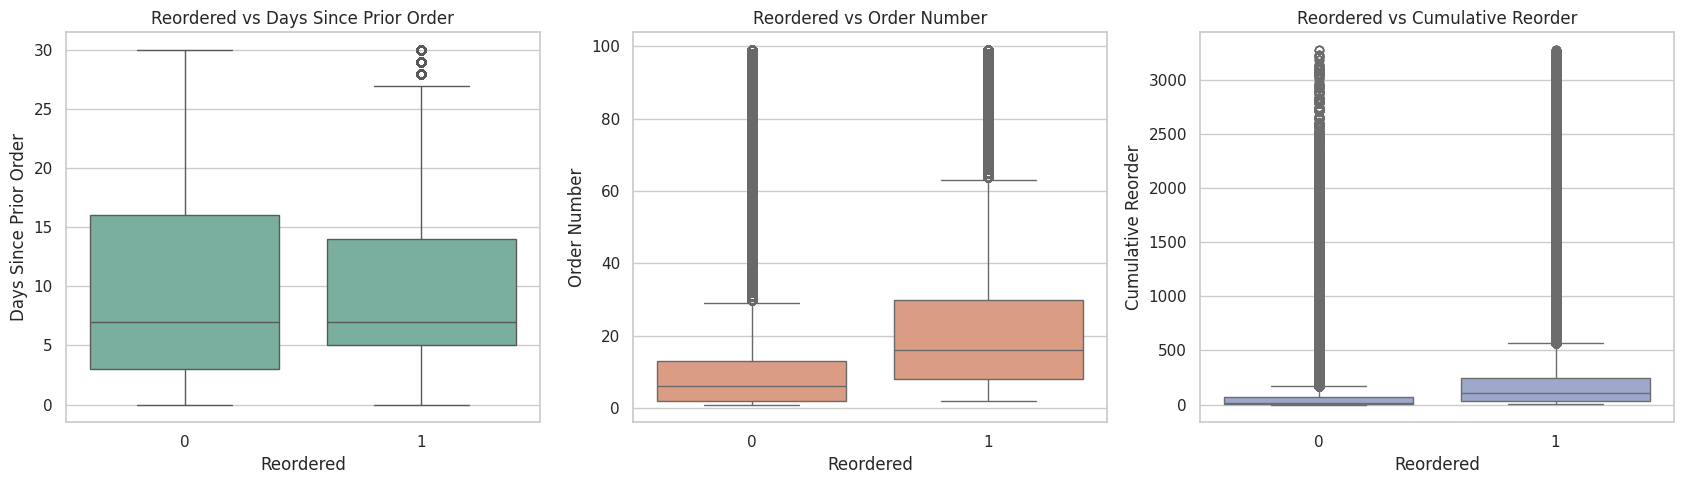

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [15]:
# Compare metrics between reordered and non-reordered items
reordered_yes = df[df["reordered"] == 1]
reordered_no = df[df["reordered"] == 0]

comparison_stats = {
    "days_since_prior_order": reordered_yes["days_since_prior_order"].mean() - reordered_no["days_since_prior_order"].mean(),
    "order_number": reordered_yes["order_number"].median() - reordered_no["order_number"].median(),
    "cumulative_reorder": reordered_yes["cumulative_reorder_per_customer"].median() - reordered_no["cumulative_reorder_per_customer"].median(),
}

pd.Series(comparison_stats, name="difference").to_frame()

,difference
days_since_prior_order,-0.44353
order_number,10.00000
cumulative_reorder,86.00000


มิติการวิเคราะห์,พฤติกรรมที่พบ (Behavior),Insight สำคัญ

⏱️ Timing,มักซื้อซ้ำทุก 7 วัน (ใกล้เคียงปกติ),เป็นเรื่องของ Habit ไม่ใช่แค่ความจำเป็น

🔢 Progression,ยิ่ง Order No. สูง ยิ่งมีโอกาส Reorder,Loyalty เพิ่มขึ้นตามจำนวนครั้งที่ซื้อ

🔁 Cumulative,กระุกตัวในกลุ่มที่มีประวัติ Reorder สูง,เป็นพฤติกรรมเฉพาะของ Power Users


🎯 Executive Summary
พฤติกรรมซื้อซ้ำขึ้นอยู่กับ Customer Maturity มากกว่าปัจจัยด้านเวลา:
    - Retention Loop: ลูกค้าใหม่โอกาสต่ำ ลูกค้าเก่าโอกาสสูง
    - Sticky Behavior: เมื่อเริ่ม Reorder แล้ว มักจะทำต่อไปเรื่อยๆ
    Key Takeaway: "Loyal users become increasingly loyal over time" — โฟกัสการรักษาฐานลูกค้าเก่าให้เหนียวแน่น เพราะยิ่งอยู่นาน ยิ่งมีมูลค่าสูงขึ้นแบบทวีคูณ

### 2.2 Order & Reorder Pattern by Day/Hour

In [16]:
# =========================
# Display settings for readability
# =========================
pd.options.display.float_format = '{:,.2f}'.format  # numeric display with comma and 2 decimals

# =========================
# Order-level aggregation
# =========================
order_level = (
    df.groupby("order_id")
    .agg(
        user_id=("user_id", "first"), # ควรเก็บ user_id ไว้ด้วยเพื่อทำ Customer Bridge ต่อไป
        order_date=("order_date", "first"),
        order_dow=("order_dow", "first"),
        order_hour_of_day=("order_hour_of_day", "first"),
        total_products=("product_id", "count"),
        reorder_rate=("reordered", "mean"), # เปลี่ยนชื่อให้ชัดว่าเป็นอัตราส่วนในตะกร้า
        days_since_prior_order=("days_since_prior_order", "max"), # ปลอดภัยกว่า 'first'
    )
    .reset_index()
)


# =========================
# Date-related columns
# =========================
order_level["order_date"] = pd.to_datetime(order_level["order_date"])
order_level["month_num"] = order_level["order_date"].dt.month # สร้างเพิ่มเพื่อให้ numeric_summary ทำงานได้
order_level["month_name"] = order_level["order_date"].dt.month_name().str[:3]
order_level["week_of_year"] = order_level["order_date"].dt.isocalendar().week.astype("Int64") # สร้างเพิ่ม

# =========================
# Weekday labels
# =========================
day_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
order_level["day_name"] = pd.Categorical(
    order_level["order_dow"].map(day_map),
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
)

# =========================
# Numeric summary (readable)
# =========================
# เลือกเฉพาะคอลัมน์ที่มีอยู่จริง
cols_to_sum = ["order_hour_of_day", "total_products", "reorder_rate", "days_since_prior_order", "month_num", "week_of_year"]
numeric_summary = order_level[cols_to_sum].describe()

# คูณ 100 เฉพาะค่าสถิติ (ไม่ใช่แถว count)
stats_idx = numeric_summary.index.difference(['count'])
numeric_summary.loc[stats_idx, "reorder_rate"] *= 100

# ใช้การแสดงผลผ่าน style หรือ round แบบระบุหลัก (แต่ต้องระวัง Error เดิม)
# วิธีแก้ที่ชัวร์ที่สุดคือ round ทั้งตารางหลังคำนวณเสร็จ
numeric_summary = numeric_summary.round(2)

# Round ทุกอย่างเป็น 2 ตำแหน่ง (หรือตามที่ต้องการ)
numeric_summary.round(2)

print("\nOrder-level numeric summary (reorder_rate in %):")
display(numeric_summary)

# =========================
# Categorical & Date summary
# =========================
if SHOW_VERBOSE_TABLES:
    print("\nOrder-level categorical summary:")
    display(order_level[["day_name", "month_name"]].describe(include="all"))

    print("\nOrder-level date summary:")
    date_summary = pd.DataFrame({
        "count": [f"{order_level['order_date'].count():,}"],
        "min": [order_level["order_date"].min()],
        "max": [order_level["order_date"].max()],
        "nunique": [order_level["order_date"].nunique()],
    }, index=["order_date"])
    display(date_summary)

# =========================
# Quality checks
# =========================
print("\nQuality checks:")
print(f"Unique orders: {order_level['order_id'].nunique():,}")
print(f"Date range: {order_level['order_date'].min().date()} to {order_level['order_date'].max().date()}")
print(f"Unique months: {order_level['month_name'].nunique()}")


Order-level numeric summary (reorder_rate in %):


,order_hour_of_day,total_products,reorder_rate,days_since_prior_order,month_num,week_of_year
count,"3,214,874.00","3,214,874.00","3,214,874.00","3,214,874.00","3,214,874.00","3,214,874.00"
mean,13.44,10.09,59.87,10.02,5.66,22.69
std,4.23,7.53,33.80,9.05,3.30,14.26
min,0.00,1.00,0.00,0.00,1.00,1.00
25%,10.00,5.00,33.33,3.00,3.00,12.00
50%,13.00,8.00,66.67,7.00,5.00,20.00
75%,16.00,14.00,90.91,14.00,8.00,32.00
max,23.00,145.00,100.00,30.00,12.00,52.00



Quality checks:
Unique orders: 3,214,874
Date range: 2014-07-01 to 2015-07-01
Unique months: 12


Column,Median (50%),Max,"Interpretation (The ""Peak"" Logic)"
order_hour_of_day,13.00,23.00,Peak: น่าจะอยู่ช่วง 10:00-16:00 (Q1-Q3) โดยมีค่ากลางที่บ่ายโมง
total_products,8.00,145.00,"Max is Outlier: คนส่วนใหญ่ซื้อ 8 ชิ้น แต่มี ""วาฬ"" สั่งทีเดียว 145 ชิ้น"
reorder_rate,66.67,100.00,High Loyalty: ค่ากลางสูงมาก สะท้อนว่าสินค้าเกินครึ่งตะกร้าคือของเดิม
days_since_prior_order,7.00,30.00,"Weekly Cycle: ลูกค้า ""ส่วนใหญ่"" กลับมาทุกอาทิตย์ (7 วัน)"

"ข้อมูลแสดงให้เห็นพฤติกรรมแบบ Right-Skewed Distribution ในจำนวนสินค้าต่อออเดอร์ โดยมีค่ากลางอยู่ที่ 8 ชิ้น แม้จะมีค่าสูงสุดถึง 145 ชิ้น ก็ตาม ส่วนช่วงเวลา Peak ของการสั่งซื้อจะเกาะกลุ่มหนาแน่นในช่วงกลางวัน (10:00 - 16:00 น.) ซึ่งสอดคล้องกับรอบการสั่งซื้อซ้ำทุก 7 วัน"

#### 2.2.1 Day-Hour KPI Grid (median-focused view)

In [17]:

order_level["day_name"] = order_level["order_dow"].map(day_map)
order_level["day_name"] = pd.Categorical(
    order_level["day_name"],
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True,
    )

# Build full 7x24 grid to make gaps explicit (instead of silently missing slots).
all_day_hour = pd.MultiIndex.from_product(
    [["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"], range(24)],
    names=["day_name", "order_hour_of_day"],
)

customer_kpi = (
    order_level.groupby(["day_name", "order_hour_of_day"], observed=False)
    .agg(
        order_count=("order_id", "nunique"),
        avg_products_per_order=("total_products", "mean"),
        median_products_per_order=("total_products", "median"),
        avg_reorder_rate=("reorder_rate", "mean"),
        median_reorder_rate=("reorder_rate", "median"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        median_days_between_orders=("days_since_prior_order", "median"),
    )
    .reindex(all_day_hour)
    .reset_index()
    .sort_values(["day_name", "order_hour_of_day"])
)

# Fill only count with 0; keep averages/medians as NaN when no orders in that slot.
customer_kpi["order_count"] = customer_kpi["order_count"].fillna(0).astype(int)

# Robust feature view for modeling: prefer median-based metrics.
customer_kpi_model = customer_kpi[[
    "day_name",
    "order_hour_of_day",
    "order_count",
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]].copy()

# Add model-friendly helper features.
customer_kpi_model["is_empty_slot"] = customer_kpi_model["order_count"].eq(0).astype(int)
customer_kpi_model["day_name_code"] = customer_kpi_model["day_name"].cat.codes

# Impute missing median-based features with global medians (fallback to 0 if all missing).
model_feature_cols = [
    "median_products_per_order",
    "median_reorder_rate",
    "median_days_between_orders",
]
missing_before = customer_kpi_model[model_feature_cols].isna().sum()

for col in model_feature_cols:
    fill_value = customer_kpi_model[col].median()
    if pd.isna(fill_value):
        fill_value = 0.0
    customer_kpi_model[col] = customer_kpi_model[col].fillna(fill_value)

missing_after = customer_kpi_model[model_feature_cols].isna().sum()

display(Markdown("### Rows per day check (should be 24 each):"))
display(customer_kpi["day_name"].value_counts().sort_index().to_frame("rows_per_day"))

display(Markdown("### Median-based view (recommended for robust analysis/modeling):"))
display(customer_kpi_model.groupby("day_name", observed=False).head(1))


if SHOW_VERBOSE_TABLES:
    show_df(missing_before.to_frame("missing_count"), title="Model feature missing values (before imputation):")
    show_df(missing_after.to_frame("missing_count"), title="Model feature missing values (after imputation):")

expected_slots = 7 * 24
actual_slots = len(customer_kpi)
total_orders_from_grid = customer_kpi["order_count"].sum()
total_orders_raw = order_level["order_id"].nunique()

print(f"Slots check: expected={expected_slots}, actual={actual_slots}")
print(f"Order coverage check: grid_sum={total_orders_from_grid:,}, raw_unique_orders={total_orders_raw:,}")

### Rows per day check (should be 24 each):

,rows_per_day
day_name,
Sun,24
Mon,24
Tue,24
Wed,24
Thu,24
Fri,24
Sat,24


### Median-based view (recommended for robust analysis/modeling):

,day_name,order_hour_of_day,order_count,median_products_per_order,median_reorder_rate,median_days_between_orders,is_empty_slot,day_name_code
0,Sun,0,3692,9.00,0.64,8.00,0,0
24,Mon,0,3475,9.00,0.67,8.00,0,1
48,Tue,0,2906,8.00,0.64,8.00,0,2
72,Wed,0,2767,8.00,0.62,8.00,0,3
96,Thu,0,2476,8.00,0.62,8.00,0,4
120,Fri,0,2989,8.00,0.62,7.00,0,5
144,Sat,0,3067,8.00,0.64,7.00,0,6


Slots check: expected=168, actual=168
Order coverage check: grid_sum=3,214,874, raw_unique_orders=3,214,874


### TOP 10 Days have High Peak OrderCount

In [18]:
customer_kpi.sort_values("order_count", ascending=False).head(10)

,day_name,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
34,Mon,10,52999,10.38,8.00,0.64,0.71,10.11,7.00
14,Sun,14,50484,11.19,10.00,0.58,0.63,10.76,7.00
15,Sun,15,50020,11.04,9.00,0.59,0.64,10.77,7.00
13,Sun,13,49997,11.17,10.00,0.59,0.64,10.78,7.00
33,Mon,9,49533,10.22,8.00,0.66,0.75,9.78,7.00
35,Mon,11,49008,10.40,8.00,0.62,0.67,10.23,7.00
12,Sun,12,47729,11.22,10.00,0.58,0.62,10.76,7.00
11,Sun,11,47357,11.31,10.00,0.59,0.64,10.77,7.00
16,Sun,16,45930,10.92,9.00,0.59,0.63,10.70,7.00
10,Sun,10,44999,11.47,10.00,0.60,0.67,10.70,7.00


### TOP Hour Days have High Peak OrderCount

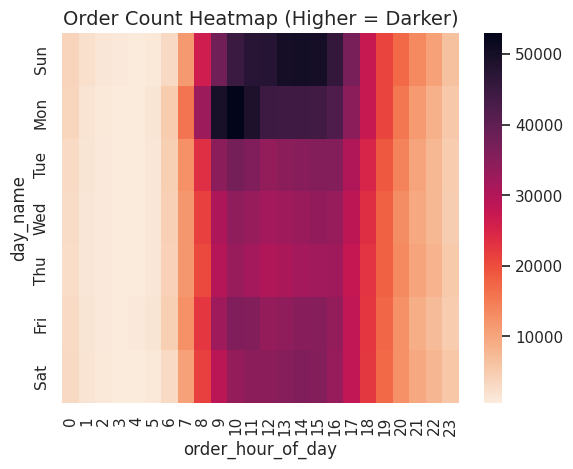

In [19]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="order_count",
 )

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Order Count Heatmap (Higher = Darker)", fontsize=14)
plt.show()

In [20]:
order_count_pivot_per_day = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="order_count"
)

print(order_count_pivot_per_day)

order_hour_of_day    0     1     2    3    4     5     6      7      8   \
day_name                                                                  
Sun                3692  2235  1299  888  750  1076  3138  11530  26223   
Mon                3475  1735  1063  711  761  1523  5101  15792  32563   
Tue                2906  1485   892  679  700  1330  4524  12550  23488   
Wed                2767  1407   889  605  666  1265  4314  11739  21305   
Thu                2476  1414   837  640  694  1251  4135  11823  20597   
Fri                2989  1539   953  796  857  1466  4573  12590  22623   
Sat                3067  1781  1137  801  747  1061  3007  10632  21522   

order_hour_of_day     9      10     11     12     13     14     15     16  \
day_name                                                                    
Sun                37990  44999  47357  47729  49997  50484  50020  45930   
Mon                49533  52999  49008  44550  44235  44220  43913  42200   
Tue             

### 📊 สรุปพฤติกรรมการสั่งซื้อจาก (Order Count)

1. **ช่วงเวลาที่มีคำสั่งซื้อสูงสุด (Peak Hours)**
   - ประมาณ **8:00 – 17:00**, โดยเฉพาะ **10:00 – 16:00**
   - ลูกค้าส่วนใหญ่สั่งซื้อในช่วงกลางวัน

2. **แนวโน้มตามวันของสัปดาห์**
   - **วันจันทร์ (Mon)** มียอดสูงสุด
   - วันพฤหัส–ศุกร์ สูงรองลงมา
   - วันเสาร์–อาทิตย์ ยอดน้อยกว่า แต่ยังมี peak กลางวัน

3. **ช่วงเวลาที่คำสั่งซื้อน้อยสุด**
   - **0:00 – 6:00** เป็นช่วงที่แทบไม่มีคำสั่งซื้อ

4. **แนวโน้มทั่วไป**
   - รูปแบบคล้าย **ระฆังกลางวัน** (bell-shaped)
   - Peak ของแต่ละวันอยู่กลางวัน ± shift เล็กน้อย

💡 **ข้อเสนอแนะเชิงธุรกิจ**
- ส่งโปรโมชันหรือแจ้งเตือน → ช่วง 10:00 – 16:00
- วางแผนพนักงาน / logistic → เพิ่มกำลังช่วงกลางวัน ลดช่วงกลางคืน
- โมเดล forecast → ใช้ feature `day_name` + `order_hour_of_day` กับ median order_count

### TOP 10 Days have average ReorderRate

In [21]:
customer_kpi.sort_values("median_reorder_rate", ascending=False).head(10)

,day_name,order_hour_of_day,order_count,avg_products_per_order,median_products_per_order,avg_reorder_rate,median_reorder_rate,avg_days_between_orders,median_days_between_orders
30,Mon,6,5101,10.35,8.00,0.66,0.75,9.82,7.00
31,Mon,7,15792,10.48,9.00,0.68,0.75,9.82,7.00
33,Mon,9,49533,10.22,8.00,0.66,0.75,9.78,7.00
32,Mon,8,32563,10.24,8.00,0.67,0.75,9.74,7.00
54,Tue,6,4524,9.69,8.00,0.65,0.74,10.04,7.00
55,Tue,7,12550,9.76,8.00,0.65,0.73,9.86,7.00
79,Wed,7,11739,9.43,8.00,0.65,0.73,9.57,7.00
7,Sun,7,11530,11.57,10.00,0.64,0.71,10.19,7.00
151,Sat,7,10632,11.06,9.00,0.64,0.71,9.90,7.00
78,Wed,6,4314,9.49,8.00,0.64,0.71,9.61,7.00


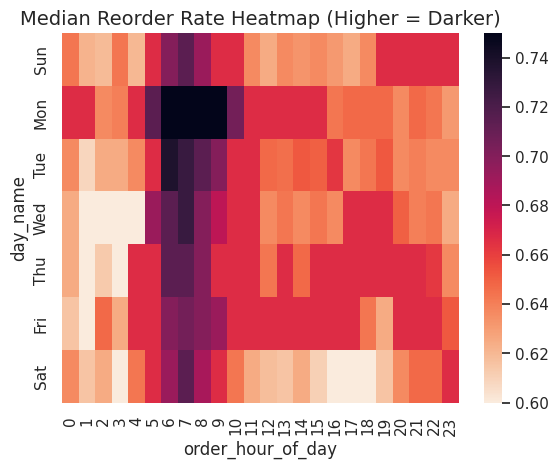

In [22]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="median_reorder_rate"
 )

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Median Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

In [23]:
reorder_rate_pivot_per_day = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="median_reorder_rate"
)

print(reorder_rate_pivot_per_day)

order_hour_of_day   0    1    2    3    4    5    6    7    8    9    10   11  \
day_name                                                                        
Sun               0.64 0.62 0.62 0.64 0.62 0.67 0.70 0.71 0.69 0.67 0.67 0.64   
Mon               0.67 0.67 0.64 0.64 0.67 0.71 0.75 0.75 0.75 0.75 0.71 0.67   
Tue               0.64 0.61 0.62 0.62 0.64 0.67 0.74 0.73 0.71 0.70 0.67 0.67   
Wed               0.62 0.60 0.60 0.60 0.60 0.69 0.71 0.73 0.70 0.68 0.67 0.67   
Thu               0.62 0.60 0.61 0.60 0.67 0.67 0.71 0.71 0.70 0.67 0.67 0.67   
Fri               0.62 0.60 0.65 0.62 0.67 0.67 0.70 0.71 0.70 0.69 0.67 0.67   
Sat               0.64 0.62 0.62 0.60 0.64 0.67 0.69 0.71 0.69 0.67 0.64 0.62   

order_hour_of_day   12   13   14   15   16   17   18   19   20   21   22   23  
day_name                                                                       
Sun               0.62 0.64 0.63 0.64 0.63 0.62 0.64 0.67 0.67 0.67 0.67 0.67  
Mon               0.67 0.67 0.

<Axes: xlabel='order_hour_of_day', ylabel='median_reorder_rate'>

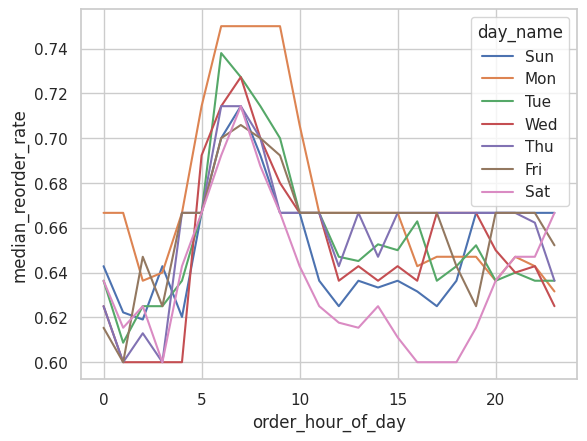

In [24]:
sns.lineplot(
    data=customer_kpi,
    x="order_hour_of_day",
    y="median_reorder_rate",
    hue="day_name"
    )

### 📊 Median Reorder Rate by Hour & Day — Key Insights

### 🔥 1. Early Morning Peak (06:00–08:00)
- ช่วงเวลา **06:00–08:00 น.** มีค่า reorder rate สูงที่สุด (~0.74–0.75)
- เห็นได้ชัดในหลายวัน โดยเฉพาะ **วันจันทร์ (Monday)**
- แสดงถึงพฤติกรรม **routine purchasing / restocking**

> 📌 Insight: ผู้ใช้ช่วงเช้ามีแนวโน้มเป็นลูกค้าประจำ (high loyalty)

---

### 📅 2. Monday Shows Strongest Reorder Behavior
- วันจันทร์มี peak สูงสุดของทั้ง dataset
- ค่า reorder สูงต่อเนื่องในช่วงเช้า

> 📌 Insight: เป็นพฤติกรรม “start-of-week restocking”

---

### 📉 3. Midday Drop (10:00–17:00)
- ช่วงสายถึงบ่าย ค่า reorder ลดลง (~0.60–0.66)
- พบ pattern นี้แทบทุกวัน

> 📌 Insight: ลูกค้ามีแนวโน้ม “explore สินค้าใหม่” มากกว่าซื้อซ้ำ

---

### 🌙 4. Evening Recovery (18:00–23:00)
- ค่า reorder กลับมาอยู่ระดับปานกลาง (~0.63–0.67)
- ไม่สูงเท่าช่วงเช้า แต่ไม่ต่ำสุด

> 📌 Insight: มีการซื้อซ้ำบ้าง แต่ไม่ใช่ช่วง peak ของ loyalty

---

### 📊 5. Clear Behavioral Pattern (Not Flat)
- ค่า reorder rate ไม่ได้คงที่ทั้งวัน
- มีความแตกต่างชัดเจนระหว่าง:
  - ช่วง peak (~0.75)
  - ช่วงต่ำ (~0.60)

> 📌 Insight: Time-of-day มีผลต่อพฤติกรรมลูกค้าอย่างมีนัยสำคัญ

---

### 📆 6. Weekday vs Weekend Behavior
- วันธรรมดา (Mon–Fri): มี pattern ชัดเจน โดยเฉพาะช่วงเช้า
- วันหยุด (Sat–Sun): ค่า reorder ต่ำกว่าเล็กน้อย และกระจายมากกว่า

> 📌 Insight: Weekend มีแนวโน้มเป็น exploratory behavior มากขึ้น

---

### 🧠 Overall Conclusion
- **Morning users = High loyalty (reorder สูง)**
- **Midday users = Exploration mode**
- **Monday = Key restocking day**
- พฤติกรรมลูกค้าเปลี่ยนตามช่วงเวลาอย่างชัดเจน

---

### 🎯 Business Implications
- 📌 Promote "reorder / subscription" → ช่วงเช้า
- 📌 Promote "new products / discovery" → ช่วงบ่าย
- 📌 Target campaigns → วันจันทร์ (high intent users)

<Axes: xlabel='day_name', ylabel='reorder_rate'>

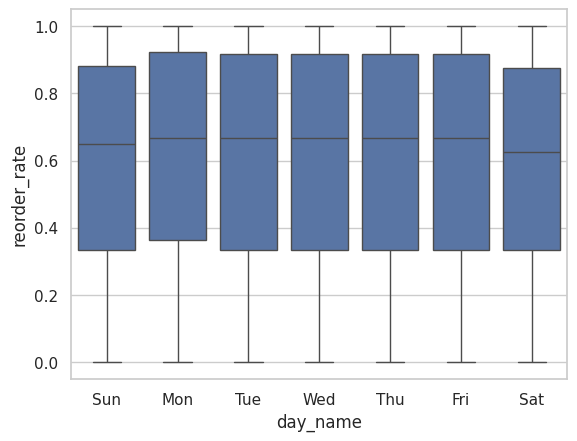

In [25]:
sns.boxplot(
    data=order_level,
    x="day_name",
    y="reorder_rate"
    )

## 5) Basket Value & Repeat Rate by Category

In [26]:
# Category-level value weight (relative, not actual price)
value_weight_map = {
    # 🟢 Fresh / Low value
    "fresh fruits": 1.0,
    "fresh vegetables": 1.0,
    "packaged vegetables fruits": 1.2,
    "fresh herbs": 1.3,
    "water seltzer sparkling water": 1.1,

    # 🟡 Dairy / Basic food
    "milk": 1.4,
    "yogurt": 1.5,
    "eggs": 1.5,
    "cream": 1.6,
    "butter": 1.6,
    "packaged cheese": 1.7,
    "other creams cheeses": 1.8,

    # 🟡 Bakery / carbs
    "bread": 1.4,
    "buns rolls": 1.4,
    "breakfast bakery": 1.5,
    "tortillas flat bread": 1.5,
    "dry pasta": 1.3,
    "grains rice dried goods": 1.3,

    # 🟡 Snacks / packaged
    "chips pretzels": 1.6,
    "crackers": 1.5,
    "cookies cakes": 1.7,
    "candy chocolate": 1.6,
    "popcorn jerky": 1.7,
    "trail mix snack mix": 1.8,
    "nuts seeds dried fruit": 1.8,

    # 🟡 Drinks
    "soft drinks": 1.4,
    "juice nectars": 1.5,
    "tea": 1.4,
    "coffee": 1.6,
    "energy sports drinks": 1.7,

    # 🔴 Protein / meat
    "meat counter": 2.5,
    "poultry counter": 2.4,
    "seafood counter": 2.7,
    "packaged meat": 2.3,
    "packaged poultry": 2.2,
    "packaged seafood": 2.4,
    "hot dogs bacon sausage": 2.2,
    "lunch meat": 2.0,

    # 🔴 Frozen / prepared
    "frozen meals": 2.0,
    "frozen produce": 1.6,
    "frozen pizza": 2.1,
    "frozen appetizers sides": 2.0,
    "frozen breakfast": 1.8,
    "prepared meals": 2.2,
    "prepared soups salads": 2.0,

    # 🔴 Pantry / cooking
    "canned meals beans": 1.6,
    "canned jarred vegetables": 1.4,
    "canned fruit applesauce": 1.4,
    "pasta sauce": 1.5,
    "condiments": 1.5,
    "spices seasonings": 1.6,
    "oils vinegars": 1.8,
    "baking ingredients": 1.5,
    "doughs gelatins bake mixes": 1.5,

    # 🔴 Special food
    "baby food formula": 2.5,
    "tofu meat alternatives": 2.2,
    "protein meal replacements": 2.6,
    "international": 1.7,
    "asian foods": 1.7,
    "latino foods": 1.6,
    "indian foods": 1.7,

    # 🟣 Premium / alcohol
    "beers coolers": 3.0,
    "red wines": 3.2,
    "white wines": 3.2,
    "spirits": 3.5,
    "specialty wines champagnes": 3.8,

    # 🟣 Non-food high value
    "cleaning products": 2.3,
    "laundry": 2.4,
    "dish detergents": 2.2,
    "paper goods": 2.0,
    "trash bags liners": 2.1,
    "air fresheners candles": 2.2,

    # 🟣 Personal care
    "personal care": 2.5,
    "oral hygiene": 2.3,
    "body lotions soap": 2.4,
    "hair care": 2.4,
    "skin care": 2.6,
    "facial care": 2.6,
    "deodorants": 2.2,
    "feminine care": 2.4,

    # 🟣 Baby / pets
    "diapers wipes": 2.8,
    "baby bath body care": 2.6,
    "baby accessories": 2.7,
    "cat food care": 2.4,
    "dog food care": 2.4,

    # fallback
    "missing": 1.5,
    "other": 1.5
}

# 2) CREATE VALUE INDEX
# =========================
df["value_weight"] = df["aisle"].map(value_weight_map)
df["value_weight"] = df["value_weight"].fillna(1.5)

df["quantity"] = 1
df["value_index"] = df["quantity"] * df["value_weight"]


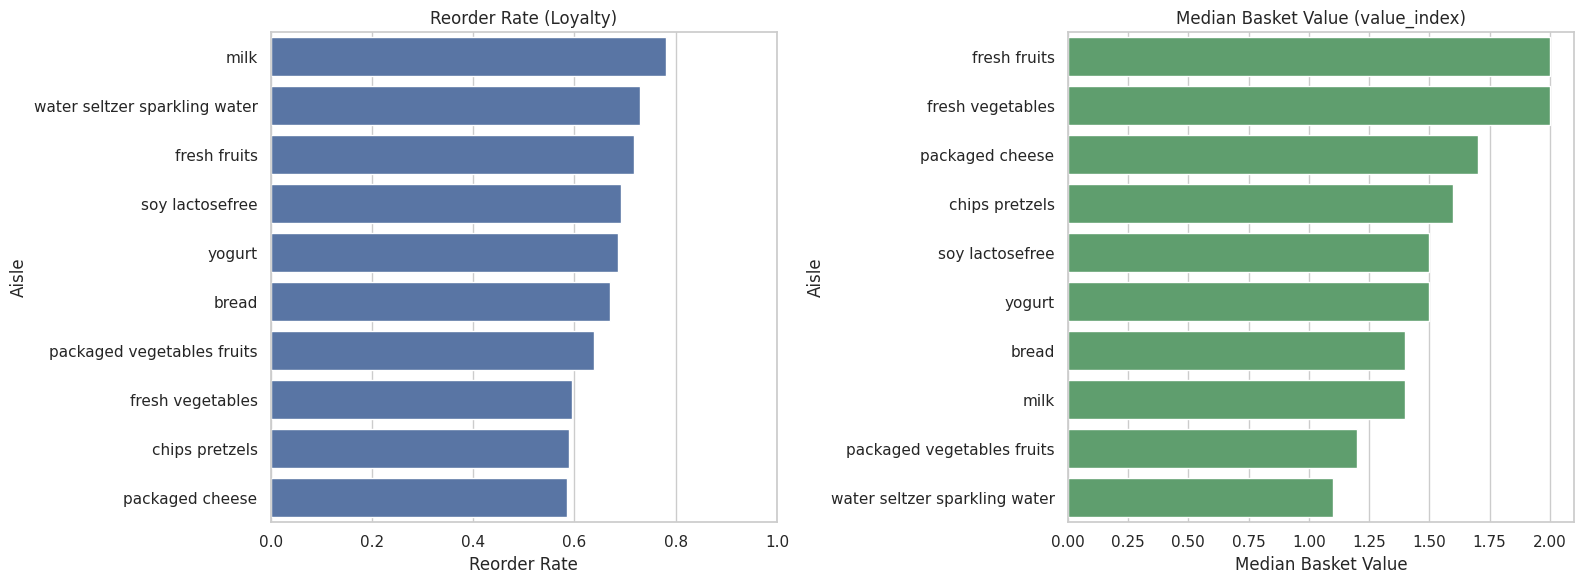

,aisle,order_lines,reorder_rate,median_basket_value
50,fresh fruits,3642188,0.72,2.00
53,fresh vegetables,3418021,0.59,2.00
98,packaged vegetables fruits,1765313,0.64,1.20
133,yogurt,1452343,0.69,1.50
93,packaged cheese,979763,0.59,1.70
83,milk,891015,0.78,1.40
131,water seltzer sparkling water,841533,0.73,1.10
25,chips pretzels,722470,0.59,1.60
119,soy lactosefree,638253,0.69,1.50
11,bread,584834,0.67,1.40


In [27]:
# 1. Config & Data Prep
CATEGORY_COL = ["aisle"]
TOP_N = 10

group_col = CATEGORY_COL[0]
category_df = df.copy()

# ถ้าไม่มีคอลัมน์ ให้ merge ใหม่
if group_col not in category_df.columns:
    category_df = category_df.merge(
        tables["products"][["product_id", group_col]].drop_duplicates(),
        on="product_id",
        how="left",
    )

# เติมค่าว่างเพื่อป้องกันปัญหาเวลา groupby
category_df[group_col] = category_df[group_col].fillna("Unknown")

# ใช้ราคาจริงถ้ามี ไม่งั้น fallback ไปใช้ value_index ที่สร้างไว้ก่อนหน้า
value_col = "total_price" if "total_price" in category_df.columns else "value_index"
if value_col not in category_df.columns:
    raise ValueError("Need `total_price` or `value_index` in df before running this cell.")

# 2. คำนวณรายบรรทัด (Repeat / Reorder Rate)
line_metrics = (
    category_df.groupby(group_col, observed=False)
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
)

# 3. คำนวณรายตะกร้า (Basket Value)
basket_metrics = (
    category_df.groupby(["order_id", group_col], observed=False)
    .agg(basket_val=(value_col, "sum"))
    .groupby(group_col, observed=False)
    .agg(median_basket_value=("basket_val", "median"))
)

# 4. รวมข้อมูลเข้าด้วยกัน
category_summary = (
    line_metrics.join(basket_metrics, how="left")
    .reset_index()
    .sort_values("order_lines", ascending=False)
    .head(TOP_N)
)

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# กราฟ 1: Reorder Rate (Loyalty)
sns.barplot(
    data=category_summary.sort_values("reorder_rate", ascending=False),
    x="reorder_rate",
    y=group_col,
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set_title("Reorder Rate (Loyalty)")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("Reorder Rate")
axes[0].set_ylabel(group_col.title())

# กราฟ 2: Median Basket Value (Monetary)
sns.barplot(
    data=category_summary.sort_values("median_basket_value", ascending=False),
    x="median_basket_value",
    y=group_col,
    ax=axes[1],
    color="#55A868",
)
axes[1].set_title(f"Median Basket Value ({value_col})")
axes[1].set_xlabel("Median Basket Value")
axes[1].set_ylabel(group_col.title())

plt.tight_layout()
plt.show()

category_summary

## 6) Customer Lifetime Value (CLV)

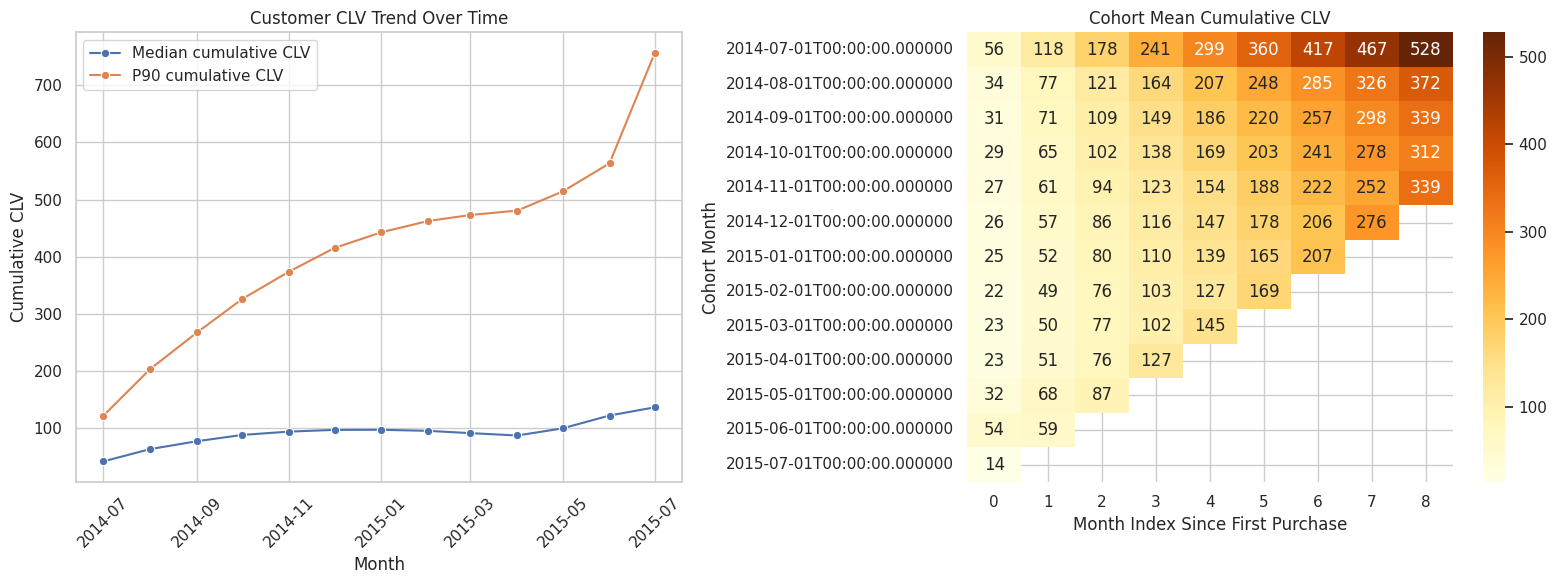

#### Customer CLV profile summary:

,total_orders,total_spend,avg_order_value,lifetime_days,orders_per_month,estimated_monthly_clv
count,"206,209.00","206,209.00","206,209.00","206,209.00","206,209.00","206,209.00"
mean,15.59,230.58,14.68,157.22,2.83,41.15
std,16.65,298.75,8.76,103.19,1.71,34.83
min,3.00,3.00,1.00,1.00,1.11,1.26
25%,5.00,57.70,8.49,67.00,1.75,18.97
50%,9.00,122.70,13.07,133.00,2.36,32.18
75%,19.00,276.20,19.01,238.00,3.31,52.60
max,99.00,"5,525.60",107.25,366.00,99.00,"1,805.36"


#### Latest CLV trend snapshot:

,order_month,active_customers,avg_monthly_spend,median_cumulative_clv,p90_cumulative_clv
7,2015-02-01,120843,32.42,95.70,462.70
8,2015-03-01,148737,34.92,91.70,473.10
9,2015-04-01,181852,35.02,87.60,480.90
10,2015-05-01,201055,35.47,100.10,514.30
11,2015-06-01,206203,32.97,122.50,563.50
12,2015-07-01,3319,14.16,136.90,756.82


In [28]:
# --- Customer Lifetime Value (CLV) trends ---
CLV_FREQ = "M"  # monthly trend
MAX_MONTH_INDEX = 8  # keep cohort chart readable

if "total_price" not in df.columns and "value_index" in df.columns:
    df["total_price"] = df["value_index"]

# Build order-level value first to avoid line-level double counting in CLV.
order_value = (
    df.groupby(["user_id", "order_id", "order_date"], observed=False)
    .agg(order_value=("total_price", "sum"))
    .reset_index()
)
order_value["order_month"] = order_value["order_date"].dt.to_period(CLV_FREQ).dt.to_timestamp()

# 1) Customer-level CLV profile
customer_clv = (
    order_value.groupby("user_id", observed=False)
    .agg(
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        total_orders=("order_id", "nunique"),
        total_spend=("order_value", "sum"),
        avg_order_value=("order_value", "mean"),
    )
    .reset_index()
)

customer_clv["lifetime_days"] = (
    customer_clv["last_order_date"] - customer_clv["first_order_date"]
).dt.days + 1
customer_clv["lifetime_months"] = np.maximum(customer_clv["lifetime_days"] / 30.0, 1)
customer_clv["orders_per_month"] = customer_clv["total_orders"] / customer_clv["lifetime_months"]
customer_clv["estimated_monthly_clv"] = customer_clv["avg_order_value"] * customer_clv["orders_per_month"]

# 2) Monthly trend of cumulative CLV per customer
customer_monthly = (
    order_value.groupby(["user_id", "order_month"], observed=False)
    .agg(monthly_spend=("order_value", "sum"))
    .reset_index()
    .sort_values(["user_id", "order_month"])
)
customer_monthly["cumulative_clv"] = customer_monthly.groupby("user_id", observed=False)["monthly_spend"].cumsum()

clv_trend = (
    customer_monthly.groupby("order_month", observed=False)
    .agg(
        active_customers=("user_id", "nunique"),
        avg_monthly_spend=("monthly_spend", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
        p90_cumulative_clv=("cumulative_clv", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)

# 3) Cohort CLV progression (by first purchase month)
cohort_base = order_value[["user_id", "order_month"]].drop_duplicates().copy()
cohort_base["cohort_month"] = cohort_base.groupby("user_id", observed=False)["order_month"].transform("min")

cohort_base["month_index"] = (
    (cohort_base["order_month"].dt.year - cohort_base["cohort_month"].dt.year) * 12 +
    (cohort_base["order_month"].dt.month - cohort_base["cohort_month"].dt.month)
)

cohort_clv = customer_monthly.merge(
    cohort_base[["user_id", "order_month", "cohort_month", "month_index"]],
    on=["user_id", "order_month"],
    how="left",
)

cohort_clv_progress = (
    cohort_clv[cohort_clv["month_index"] <= MAX_MONTH_INDEX]
    .groupby(["cohort_month", "month_index"], observed=False)
    .agg(
        customers=("user_id", "nunique"),
        mean_cumulative_clv=("cumulative_clv", "mean"),
        median_cumulative_clv=("cumulative_clv", "median"),
    )
    .reset_index()
)

cohort_clv_pivot = cohort_clv_progress.pivot(
    index="cohort_month",
    columns="month_index",
    values="mean_cumulative_clv",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="median_cumulative_clv",
    marker="o",
    label="Median cumulative CLV",
    ax=axes[0],
)
sns.lineplot(
    data=clv_trend,
    x="order_month",
    y="p90_cumulative_clv",
    marker="o",
    label="P90 cumulative CLV",
    ax=axes[0],
)
axes[0].set_title("Customer CLV Trend Over Time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Cumulative CLV")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cohort_clv_pivot, annot=True, fmt=".0f", cmap="YlOrBr", ax=axes[1])
axes[1].set_title("Cohort Mean Cumulative CLV")
axes[1].set_xlabel("Month Index Since First Purchase")
axes[1].set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()

show_df(
    customer_clv[[
        "total_orders",
        "total_spend",
        "avg_order_value",
        "lifetime_days",
        "orders_per_month",
        "estimated_monthly_clv",
    ]].describe(),
    title="Customer CLV profile summary:",
)
show_df(clv_trend.tail(6), title="Latest CLV trend snapshot:")

if SHOW_VERBOSE_TABLES:
    show_df(cohort_clv_progress.head(20), title="Cohort CLV progression sample:")

### 6.2 Order Funnel (% Customers Reaching Each Order)

วิเคราะห์ drop-off ของลูกค้าตามจำนวน order สะสม

- Funnel bar chart: % ลูกค้าที่มีอย่างน้อย N orders
- Drop-off rate: % ที่หายไประหว่างแต่ละขั้น
- Segment funnel: เปรียบเทียบ Whales / Regulars / Churned

In [29]:
# --- Order Funnel ---
FUNNEL_MAX_ORDER = 15  # show up to order #15

# Customer max order number (total_orders per customer)
user_max_order = (
    df.groupby("user_id", observed=False)["order_number"]
    .max()
    .reset_index()
    .rename(columns={"order_number": "max_order"})
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
user_max_order["segment"] = user_max_order["segment"].fillna("Unknown")

total_customers = user_max_order["user_id"].nunique()

# Overall funnel: % of customers with max_order >= n
funnel_steps = range(1, FUNNEL_MAX_ORDER + 1)
funnel = pd.DataFrame(
    {
        "order_n": list(funnel_steps),
        "customers_reached": [
            (user_max_order["max_order"] >= n).sum() for n in funnel_steps
        ],
    }
)
funnel["pct_of_total"] = funnel["customers_reached"] / total_customers
funnel["drop_off_pct"] = funnel["pct_of_total"].diff(-1).clip(lower=0)

# Segment funnel
seg_funnel_rows = []
for seg in SEGMENT_ORDER + ["Unknown"]:
    seg_users = user_max_order[user_max_order["segment"] == seg]
    n_seg = len(seg_users)
    if n_seg == 0:
        continue
    for n in funnel_steps:
        seg_funnel_rows.append(
            {
                "segment": seg,
                "order_n": n,
                "pct_reached": (seg_users["max_order"] >= n).sum() / n_seg,
            }
        )
seg_funnel = pd.DataFrame(seg_funnel_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall funnel bar chart
bar_colors = ["#4C72B0" if n <= 5 else "#AABDD4" for n in funnel["order_n"]]
axes[0].bar(funnel["order_n"], funnel["pct_of_total"] * 100, color=bar_colors, edgecolor="white")
axes[0].set_title(f"Order Funnel — % Customers Reaching Each Order\n(N={total_customers:,})")
axes[0].set_xlabel("Order number (>= N)")
axes[0].set_ylabel("% of customers")
axes[0].set_xticks(list(funnel_steps))

# Segment funnel line chart
seg_palette = dict(zip(SEGMENT_ORDER, ["#4C72B0", "#55A868", "#C44E52"]))
for seg in SEGMENT_ORDER:
    seg_data = seg_funnel[seg_funnel["segment"] == seg]
    if not seg_data.empty:
        axes[1].plot(
            seg_data["order_n"],
            seg_data["pct_reached"] * 100,
            marker="o",
            label=seg,
            color=seg_palette.get(seg),
            linewidth=2,
        )
axes[1].set_title("Order Funnel by Segment")
axes[1].set_xlabel("Order number (>= N)")
axes[1].set_ylabel("% of segment customers")
axes[1].set_xticks(list(funnel_steps))
axes[1].legend(title="Segment")

plt.tight_layout()
plt.show()

show_df(funnel, title="Overall funnel table:")

# Key drop-off points (drop > 5%)
big_drops = funnel[funnel["drop_off_pct"] > 0.05].copy()
show_df(big_drops[["order_n", "pct_of_total", "drop_off_pct"]], title="Big drop-off points (>5%):")

NameError: name 'rfm' is not defined

### 6.3 First Purchase Category (Gateway Category)

หา "gateway category" ที่พาลูกค้าใหม่เข้าสู่การเป็น Whales

- Top departments/aisles ในออร์เดอร์แรก (`order_number = 1`)
- เปรียบเทียบตาม segment
- Conversion insight: gateway category ไหนมีสัดส่วนกลายเป็น Whales สูง

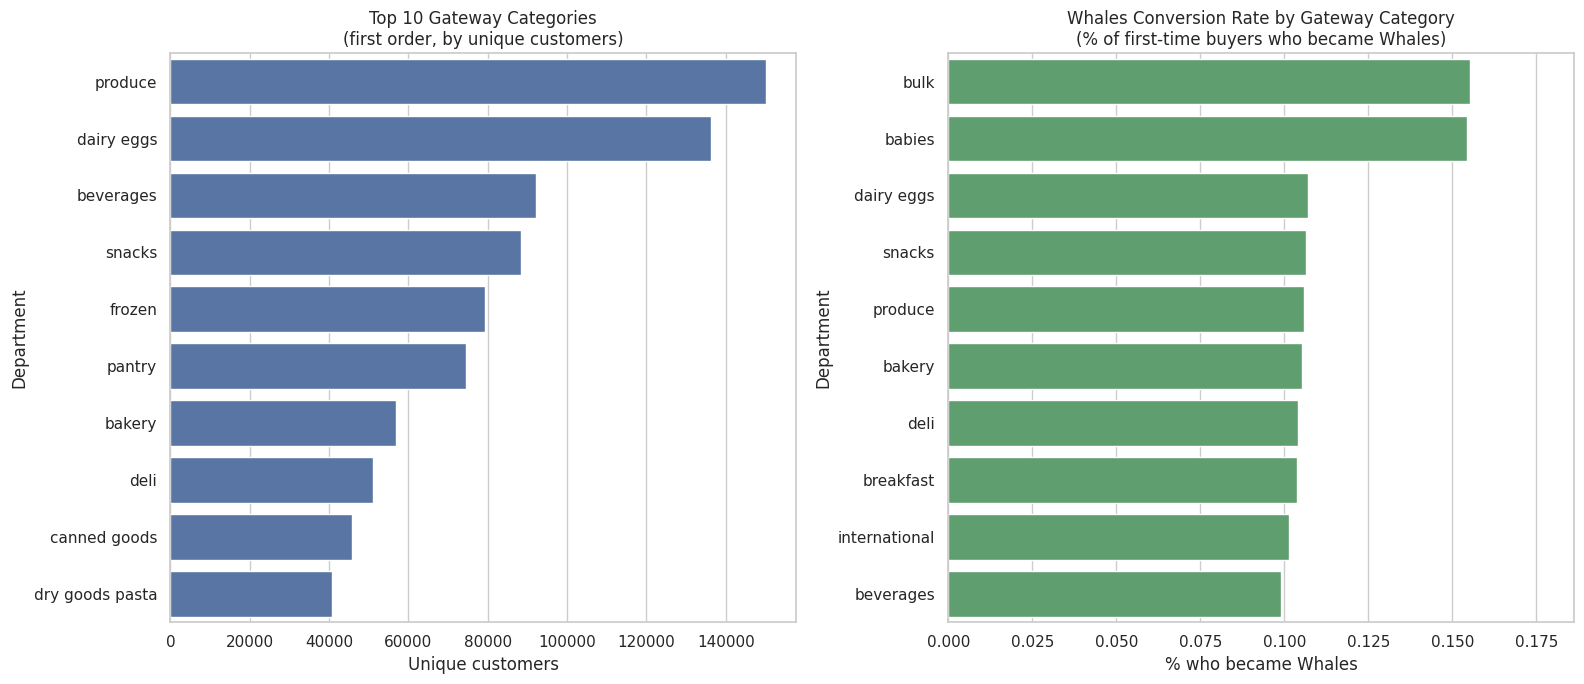

Overall top gateway categories (department):


,department,customers,order_lines,pct_of_new_customers
0,produce,150245,584384,0.73
1,dairy eggs,136272,333030,0.66
2,beverages,92264,167618,0.45
3,snacks,88331,180909,0.43
4,frozen,79311,158323,0.38
5,pantry,74426,128268,0.36
6,bakery,56870,75541,0.28
7,deli,51136,70099,0.25
8,canned goods,45911,73766,0.22
9,dry goods pasta,40797,60982,0.20


Top gateway categories by segment:


,segment,department,customers,pct_in_segment
0,Whales,produce,15903,0.16
1,Whales,dairy eggs,14576,0.15
2,Whales,snacks,9412,0.09
3,Whales,beverages,9127,0.09
4,Whales,frozen,7599,0.08
5,Whales,pantry,7314,0.07
6,Whales,bakery,5986,0.06
7,Whales,deli,5325,0.05
8,Whales,canned goods,4145,0.04
9,Whales,dry goods pasta,3928,0.04


Whales conversion rate by gateway category:


,department,whale_conversion_rate
0,bulk,0.16
1,babies,0.15
2,dairy eggs,0.11
3,snacks,0.11
4,produce,0.11
5,bakery,0.11
6,deli,0.10
7,breakfast,0.10
8,international,0.10
9,beverages,0.10


In [ ]:
# --- First Purchase Category ---
TOP_N_GATEWAY = 10
GATEWAY_COL = "department"  # switch to "aisle" for finer granularity

first_order_df = df[df["order_number"] == 1].copy()

# Ensure department/aisle column exists
if GATEWAY_COL not in first_order_df.columns:
    product_dim_gw = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE, project_root=PROJECT_ROOT
    )[["product_id", GATEWAY_COL]]
    first_order_df = first_order_df.merge(product_dim_gw, on="product_id", how="left")

first_order_df[GATEWAY_COL] = first_order_df[GATEWAY_COL].fillna("Unknown")

# 1) Overall top gateway categories
gateway_overall = (
    first_order_df.groupby(GATEWAY_COL, observed=False)
    .agg(customers=("user_id", "nunique"), order_lines=("product_id", "count"))
    .reset_index()
    .sort_values("customers", ascending=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)
gateway_overall["pct_of_new_customers"] = (
    gateway_overall["customers"] / first_order_df["user_id"].nunique()
)

# 2) Gateway by segment — which category did each segment start with?
rfm_segment = rfm[["user_id", "segment"]].copy()
if "segment" in first_order_df.columns:
    first_order_seg = first_order_df.drop(columns=["segment"]).merge(
        rfm_segment, on="user_id", how="left"
    )
else:
    first_order_seg = first_order_df.merge(rfm_segment, on="user_id", how="left")

first_order_seg["segment"] = first_order_seg["segment"].fillna("Unknown")

gateway_by_segment = (
    first_order_seg.groupby(["segment", GATEWAY_COL], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
seg_totals = gateway_by_segment.groupby("segment", observed=False)["customers"].transform("sum")
gateway_by_segment["pct_in_segment"] = gateway_by_segment["customers"] / seg_totals

top_gateway_by_segment = (
    gateway_by_segment.sort_values(["segment", "customers"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)

# 3) Conversion: for each gateway category, what % ended up as Whales?
whales_first = (
    first_order_seg.groupby([GATEWAY_COL, "segment"], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
cat_totals = whales_first.groupby(GATEWAY_COL, observed=False)["customers"].transform("sum")
whales_first["pct_in_cat"] = whales_first["customers"] / cat_totals

whale_conversion = (
    whales_first[whales_first["segment"] == "Whales"]
    [[GATEWAY_COL, "pct_in_cat"]]
    .rename(columns={"pct_in_cat": "whale_conversion_rate"})
    .sort_values("whale_conversion_rate", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=gateway_overall,
    x="customers",
    y=GATEWAY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Top {TOP_N_GATEWAY} Gateway Categories\n(first order, by unique customers)")
axes[0].set_xlabel("Unique customers")
axes[0].set_ylabel(GATEWAY_COL.title())

# Whales conversion rate by gateway category (top 10)
top_whale_conv = whale_conversion.head(TOP_N_GATEWAY)
sns.barplot(
    data=top_whale_conv,
    x="whale_conversion_rate",
    y=GATEWAY_COL,
    color="#55A868",
    ax=axes[1],
)
axes[1].set_title(f"Whales Conversion Rate by Gateway Category\n(% of first-time buyers who became Whales)")
axes[1].set_xlabel("% who became Whales")
axes[1].set_ylabel(GATEWAY_COL.title())
if not top_whale_conv.empty:
    axes[1].set_xlim(0, top_whale_conv["whale_conversion_rate"].max() * 1.2)

plt.tight_layout()
plt.show()

show_df(gateway_overall, title=f"Overall top gateway categories ({GATEWAY_COL}):")
show_df(top_gateway_by_segment, title="Top gateway categories by segment:")
show_df(whale_conversion, title="Whales conversion rate by gateway category:")

## 7) Trend Deep Dive (User & Product)

In [ ]:
# --- User trend + Product trend (Top N + Share) ---
TREND_FREQ = "W"  # use "M" for monthly
TOP_N_PRODUCTS = 8
TOP_N_DEPARTMENTS = 6

trend_df = df.copy()
trend_df["period"] = trend_df["order_date"].dt.to_period(TREND_FREQ).dt.to_timestamp()

# User trend metrics
user_trend = (
    trend_df.groupby("period", observed=False)
    .agg(
        active_users=("user_id", "nunique"),
        orders=("order_id", "nunique"),
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)
user_trend["orders_per_active_user"] = user_trend["orders"] / user_trend["active_users"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=user_trend, x="period", y="active_users", marker="o", ax=axes[0], label="active_users")
sns.lineplot(data=user_trend, x="period", y="orders_per_active_user", marker="o", ax=axes[0], label="orders_per_active_user")
axes[0].set_title(f"User Trend ({TREND_FREQ})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Count / Ratio")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=user_trend, x="period", y="reorder_rate", marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title(f"Reorder Rate Trend ({TREND_FREQ})")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(user_trend, title="User trend summary:")

# Product trend prep: ensure department exists
if "department" not in trend_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "department"]]
    trend_df = trend_df.merge(product_dim, on="product_id", how="left")

period_total_lines = (
    trend_df.groupby("period", observed=False)
    .size()
    .rename("total_lines_period")
    .reset_index()
)

# Top N products by overall order lines
top_products = (
    trend_df["product_name"].value_counts().head(TOP_N_PRODUCTS).index.tolist()
)
product_period = (
    trend_df[trend_df["product_name"].isin(top_products)]
    .groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
product_period["share_of_total"] = product_period["order_lines"] / product_period["total_lines_period"]

# Top N departments by overall order lines
top_departments = (
    trend_df["department"].dropna().value_counts().head(TOP_N_DEPARTMENTS).index.tolist()
)
dept_period = (
    trend_df[trend_df["department"].isin(top_departments)]
    .groupby(["period", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
dept_period["share_of_total"] = dept_period["order_lines"] / dept_period["total_lines_period"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(
    data=product_period,
    x="period",
    y="order_lines",
    hue="product_name",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Top {TOP_N_PRODUCTS} Products: Order Lines Trend ({TREND_FREQ})")
axes[0, 0].set_xlabel("Period")
axes[0, 0].set_ylabel("Order lines")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=product_period,
    x="period",
    y="share_of_total",
    hue="product_name",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"Top {TOP_N_PRODUCTS} Products: Share of Total ({TREND_FREQ})")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Share of total")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="order_lines",
    hue="department",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Order Lines Trend ({TREND_FREQ})")
axes[1, 0].set_xlabel("Period")
axes[1, 0].set_ylabel("Order lines")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="share_of_total",
    hue="department",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Share of Total ({TREND_FREQ})")
axes[1, 1].set_xlabel("Period")
axes[1, 1].set_ylabel("Share of total")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(product_period.sort_values(["product_name", "period"]), title="Product trend sample:")
show_df(dept_period.sort_values(["department", "period"]), title="Department trend sample:")

## 8) Distribution Diagnostics (Histogram Supplements)

ใช้ histogram เพื่ออ่าน shape ของการกระจาย (ไม่ใช่ time trend)
- `days_since_prior_order`
- `orders_per_user`
- `product_growth_rate` ข้ามช่วงเวลา

In [ ]:
# --- Histogram supplements ---

# 1) Distribution of days_since_prior_order
days_dist = df["days_since_prior_order"].dropna()

# 2) Distribution of order frequency per user
user_order_freq = (
    df.groupby("user_id", observed=False)["order_id"]
    .nunique()
    .rename("orders_per_user")
)

# 3) Distribution of product growth rate between periods
growth_base = (
    trend_df.groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
growth_base = growth_base.sort_values(["product_name", "period"])
growth_base["product_growth_rate"] = growth_base.groupby("product_name", observed=False)["order_lines"].pct_change()

# Keep finite growth values for histogram
growth_values = growth_base["product_growth_rate"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(days_dist, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution: days_since_prior_order")
axes[0].set_xlabel("Days since prior order")
axes[0].set_ylabel("Frequency")

sns.histplot(user_order_freq, bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution: orders per user")
axes[1].set_xlabel("Orders per user")
axes[1].set_ylabel("Frequency")

sns.histplot(growth_values, bins=20, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Distribution: product growth rate ({TREND_FREQ})")
axes[2].set_xlabel("Growth rate (period-over-period)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

show_df(user_order_freq.describe().to_frame(name="orders_per_user"), title="orders_per_user summary:")
show_df(growth_values.describe().to_frame(name="product_growth_rate"), title="product_growth_rate summary:")

# --- Executive summary block (auto-refresh after re-run) ---
segment_snapshot = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
segment_snapshot["user_share"] = segment_snapshot["users"] / segment_snapshot["users"].sum()

print("\n=== Executive Summary (Quick Read) ===")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Orders: {df['order_id'].nunique():,}")
print(f"Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()}")
show_df(segment_snapshot, title="Segment snapshot:")

top5 = df["product_name"].value_counts().head(5).rename("order_lines").to_frame()
show_df(top5, title="Top 5 products overall (order lines):")

print("Overall reorder rate:", f"{df['reordered'].mean():.2%}")
print("Median days_since_prior_order:", f"{df['days_since_prior_order'].median():.1f}")

## 9) Executive Summary (Interpretation Template)

ใช้ checklist นี้ตอนสรุปผลประชุม/พรีเซนต์

- Segment story: Whales / Regulars / Churned ต่างกันที่อะไร (order frequency, reorder, recency)
- Time-slot story: วันและชั่วโมงไหนมีทั้ง volume และ reorder สูง
- Category story: หมวดไหน repeat สูง และหมวดไหนมูลค่าตะกร้าสูง
- Risk story: threshold churn ที่เหมาะกับธุรกิจ และ segment ไหนเสี่ยงสุด
- Action story: แผนที่ควรทำทันที 3 อย่าง (retain Whales, grow Regulars, win-back Churned)

หมายเหตุ: ให้รัน cell summary ก่อนหน้าเพื่ออัปเดตตัวเลขล่าสุดทุกครั้ง